Loaded data: (328959, 85) in 1.9s
Class counts after grouping: {'NoMeasure': 162194, 'I': 122387, 'A': 29603, 'C': 7334, 'B': 3389, 'F': 1677, 'G': 766, 'J': 682, 'E': 248, 'H': 213, 'D': 189, 'Other': 173, 'L': 104}
Encoded classes: {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'L', 11: 'NoMeasure', 12: 'Other'}
Train/Test split: 263167 / 65792 rows
Categorical columns: []
Features ready: 69 columns
Sample‐weight range: 2.0 – 3170.7

=== K-Nearest Neighbors Classifier
Reduced dimensions from 69 to 5

Iniciando entrenamiento...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Entrenamiento completado en 9.8 segundos

Evaluando modelo...
Evaluación completada en 0.3 segundos
              precision    recall  f1-score   support

           0       0.29      0.18      0.22      5921
           1       0.20      0.10      0.14       678
           2       0.34      0.25      0.28      1467
           3       0.16      0.11      0.13      

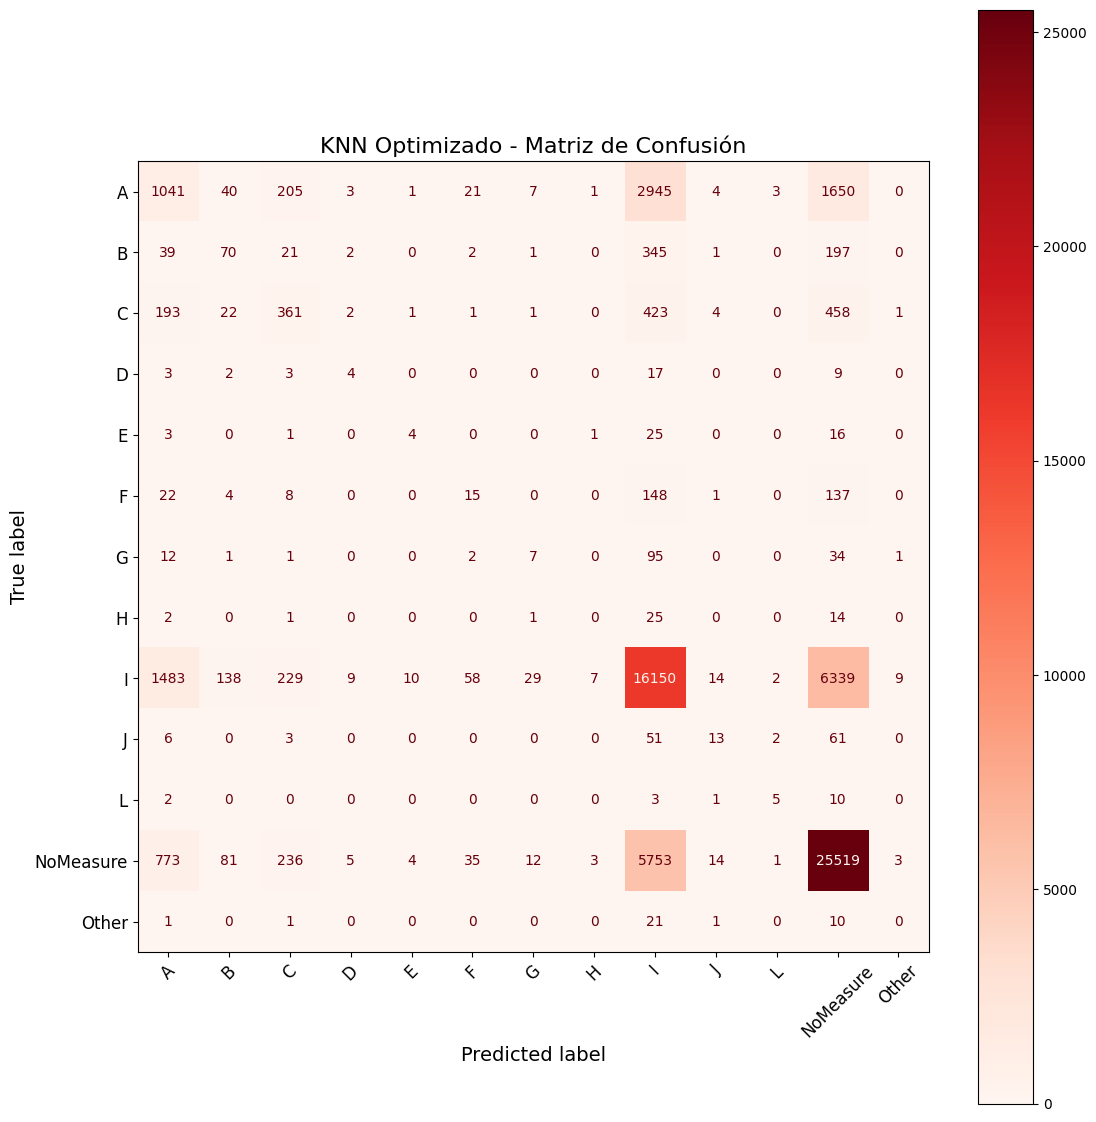


Mejores parámetros encontrados:
{'knn__leaf_size': 20, 'knn__n_neighbors': 7, 'knn__p': 2, 'knn__weights': 'distance'}


In [3]:
# ──────────────────────────────────────────────────────────────────────
# D) K-Nearest Neighbors (KNN) Classifier
# ──────────────────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

import os, time
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


# ─────────── Configurar uso de 8 núcleos ───────────
os.environ["OMP_NUM_THREADS"]      = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"]      = "2"

# ─────────── Step 1: Carga y creación del target ───────────
t0 = time.time()
df = pd.read_csv("todoscsvs_transformado.csv")
print(f"Loaded data: {df.shape} in {time.time()-t0:.1f}s")

measures = list("ABCDEFGHIJKLMNÑO")
df["target"] = df[measures].idxmax(axis=1)
df.loc[df[measures].sum(axis=1)==0, "target"] = "NoMeasure"
counts = df["target"].value_counts()
rare   = counts[counts < 100].index.tolist()
df["target_grouped"] = df["target"].apply(lambda x: "Other" if x in rare else x)
print("Class counts after grouping:", df["target_grouped"].value_counts().to_dict())

# ─────────── Step 2: Separar features y etiqueta ───────────
X_raw = df.drop(columns=measures + ["target", "target_grouped"])
y_raw = df["target_grouped"]
le    = LabelEncoder()
y     = le.fit_transform(y_raw)
print("Encoded classes:", dict(enumerate(le.classes_)))

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train/Test split: {X_train_raw.shape[0]} / {X_test_raw.shape[0]} rows")

# ─────────── Step 3: Imputación y encoding ───────────
# 3.1 Imputar numéricos con mediana
num_cols   = X_train_raw.select_dtypes(include=[np.number]).columns
medians    = X_train_raw[num_cols].median()
X_train_raw[num_cols] = X_train_raw[num_cols].fillna(medians)
X_test_raw[num_cols]  = X_test_raw[num_cols].fillna(medians)

# 3.2 Identificar categóricas y ordinal encode
cat_cols = X_train_raw.select_dtypes(include=["object","category"]).columns.tolist()
print("Categorical columns:", cat_cols)
for c in cat_cols:
    X_train_raw[c] = X_train_raw[c].fillna("Missing").astype(str)
    X_test_raw[c]  = X_test_raw[c].fillna("Missing").astype(str)

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
if cat_cols:
    X_train_raw[cat_cols] = enc.fit_transform(X_train_raw[cat_cols])
    X_test_raw[cat_cols]  = enc.transform(X_test_raw[cat_cols])

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
print(f"Features ready: {X_train.shape[1]} columns")

# ─────────── Step 4: Sample weights para balance ───────────
train_counts   = Counter(y_train)
total          = len(y_train)
sample_weight  = np.array([ total/train_counts[c] for c in y_train ])
print(f"Sample‐weight range: {sample_weight.min():.1f} – {sample_weight.max():.1f}")

def plot_confusion(y_true, y_pred, title, classes, cmap):
    cm   = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12,12))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(
        ax=plt.gca(),
        cmap=cmap,
        values_format='d',
        xticks_rotation=45,
        include_values=True
    )
    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=14)
    plt.ylabel("True label", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout(pad=3.0)
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# D) K-Nearest Neighbors (KNN) Classifier -
# ──────────────────────────────────────────────────────────────────────
print("\n=== K-Nearest Neighbors Classifier")


if X_train.shape[1] > 50:  
    pca = PCA(n_components=0.95, random_state=42)  
    X_train_reduced = pca.fit_transform(X_train)
    X_test_reduced = pca.transform(X_test)
    print(f"Reduced dimensions from {X_train.shape[1]} to {X_train_reduced.shape[1]}")
else:
    X_train_reduced = X_train.copy()
    X_test_reduced = X_test.copy()


knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(algorithm='auto', leaf_size=30, n_jobs=8)) 
])

# Búsqueda de parámetros más eficiente
knn_params = [
    {
        'knn__n_neighbors': [5, 7],  
        'knn__weights': ['distance'],  
        'knn__p': [2],  
        'knn__leaf_size': [20, 30] 
    }
]

# GridSearchCV optimizado
knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=3,  
    scoring='f1_weighted',
    n_jobs=4,  
    verbose=1
)


t4 = time.time()
print("\nIniciando entrenamiento...")
knn.fit(X_train_reduced, y_train)
print(f"\nEntrenamiento completado en {time.time()-t4:.1f} segundos")

# Evaluación optimizada
print("\nEvaluando modelo...")
t5 = time.time()
preds = knn.predict(X_test_reduced)
print(f"Evaluación completada en {time.time()-t5:.1f} segundos")

print(classification_report(y_test, preds, zero_division=0))
plot_confusion(y_test, preds, f"KNN Optimizado - Matriz de Confusión", le.classes_, cmap="Reds")

# Resultados finales
print("\nMejores parámetros encontrados:")
print(knn.best_params_)








=== KNN Modelo 2: Configuración Robusta ===

Entrenando KNN Robusto...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Entrenado en 146.3 segundos
              precision    recall  f1-score   support

           0       0.32      0.16      0.21      5921
           1       0.22      0.09      0.12       678
           2       0.37      0.24      0.29      1467
           3       0.17      0.08      0.11        38
           4       0.19      0.06      0.09        50
           5       0.15      0.04      0.07       335
           6       0.15      0.04      0.06       153
           7       0.00      0.00      0.00        43
           8       0.63      0.67      0.65     24477
           9       0.26      0.09      0.13       136
          10       0.33      0.19      0.24        21
          11       0.74      0.80      0.77     32439
          12       0.00      0.00      0.00        34

    accuracy                           0.67     65792
   macro avg       0.27    

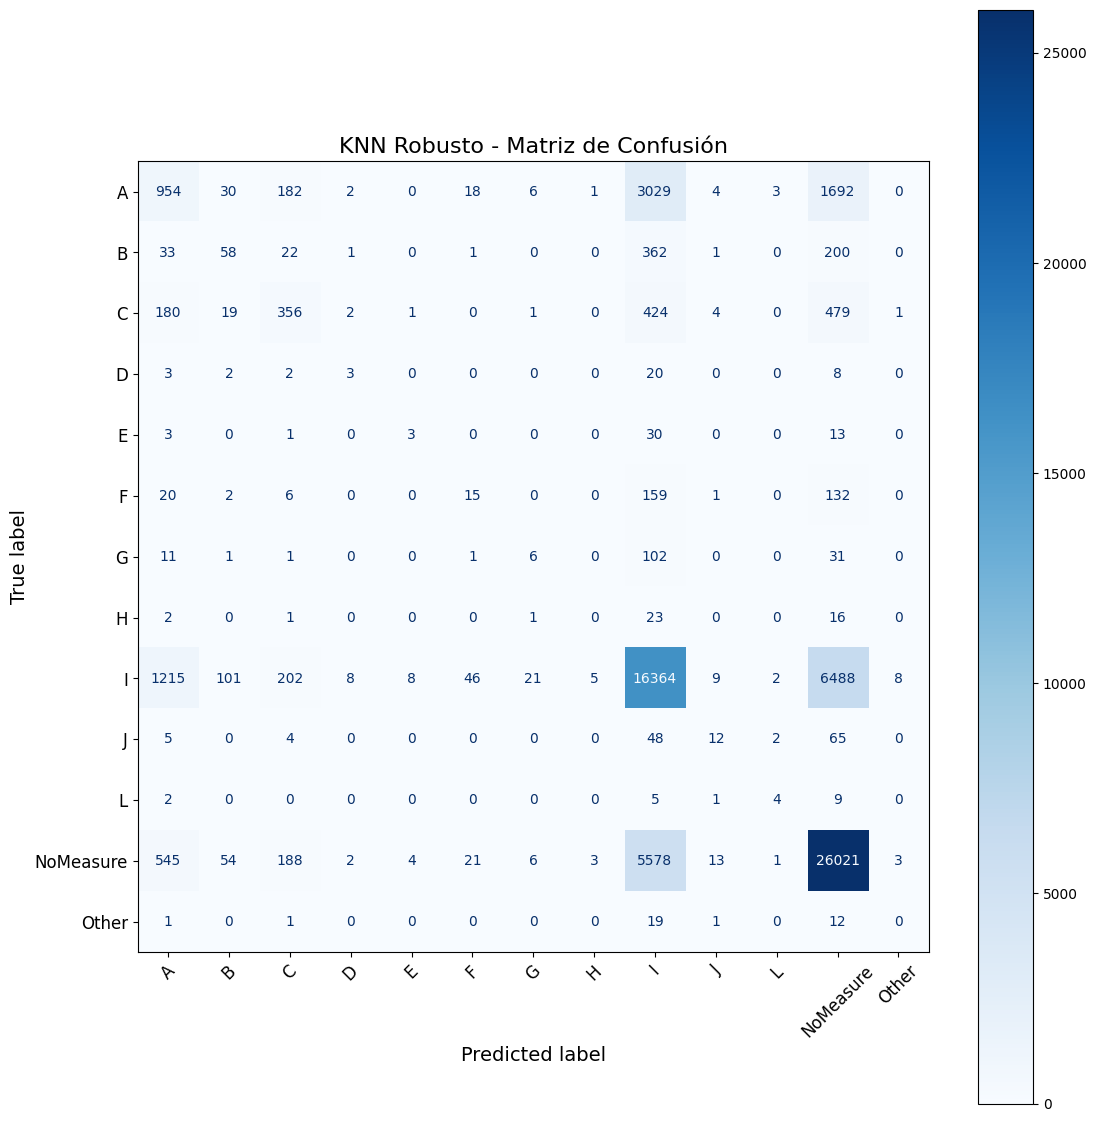


Mejores parámetros (robustos):
{'knn__algorithm': 'ball_tree', 'knn__leaf_size': 20, 'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'distance'}


In [4]:
# ──────────────────────────────────────────────────────────────────────
# D2) KNN - Configuración Robusta 
# ──────────────────────────────────────────────────────────────────────
print("\n=== KNN Modelo 2: Configuración Robusta ===")

knn_pipeline_robust = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Hiperparámetros para robustez
knn_params_robust = [
    {
        'knn__n_neighbors': [7, 9, 11],  
        'knn__weights': ['distance'],    
        'knn__p': [1],                   
        'knn__leaf_size': [20, 30],
        'knn__algorithm': ['ball_tree']  
    }
]

# Configuración de búsqueda
knn_robust = GridSearchCV(
    estimator=knn_pipeline_robust,
    param_grid=knn_params_robust,
    cv=3,
    scoring='f1_weighted',
    n_jobs=4,
    verbose=1
)

# Entrenamiento
t6 = time.time()
print("\nEntrenando KNN Robusto...")
knn_robust.fit(X_train_reduced, y_train)
print(f"\nEntrenado en {time.time()-t6:.1f} segundos")

# Evaluación
preds_robust = knn_robust.predict(X_test_reduced)
print(classification_report(y_test, preds_robust, zero_division=0))
plot_confusion(y_test, preds_robust, "KNN Robusto - Matriz de Confusión", le.classes_, cmap="Blues")

print("\nMejores parámetros (robustos):")
print(knn_robust.best_params_)


=== KNN Modelo 3: Configuración de Precisión ===

Entrenando KNN de Precisión...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Entrenado en 24.7 segundos
              precision    recall  f1-score   support

           0       0.26      0.19      0.22      5921
           1       0.19      0.09      0.12       678
           2       0.32      0.24      0.27      1467
           3       0.11      0.05      0.07        38
           4       0.25      0.02      0.04        50
           5       0.15      0.04      0.07       335
           6       0.12      0.02      0.03       153
           7       0.20      0.02      0.04        43
           8       0.60      0.66      0.63     24477
           9       0.35      0.07      0.11       136
          10       0.29      0.10      0.14        21
          11       0.74      0.74      0.74     32439
          12       0.00      0.00      0.00        34

    accuracy                           0.64     65792
   macro avg      

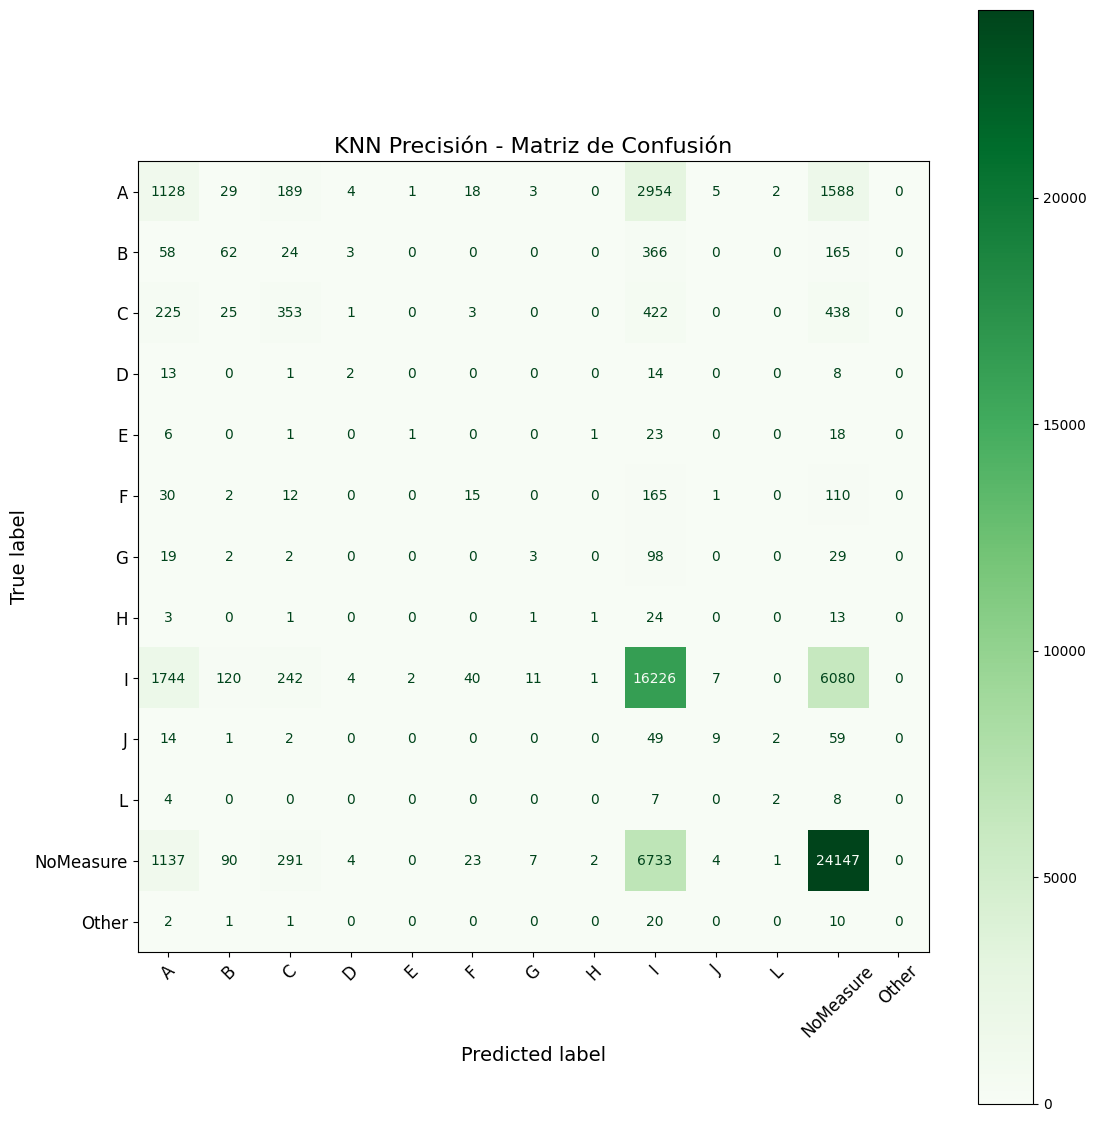


Mejores parámetros (precisión):
{'knn__algorithm': 'kd_tree', 'knn__leaf_size': 10, 'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}


In [5]:
# ──────────────────────────────────────────────────────────────────────
# D3) KNN - Configuración de Alta Precisión
# ──────────────────────────────────────────────────────────────────────
print("\n=== KNN Modelo 3: Configuración de Precisión ===")

knn_pipeline_precision = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Hiperparámetros para precisión
knn_params_precision = [
    {
        'knn__n_neighbors': [3, 5],      
        'knn__weights': ['uniform'],     
        'knn__p': [2],                    
        'knn__leaf_size': [10, 15],       
        'knn__algorithm': ['kd_tree']     
    }
]

# Configuración de búsqueda
knn_precision = GridSearchCV(
    estimator=knn_pipeline_precision,
    param_grid=knn_params_precision,
    cv=3,
    scoring='f1_weighted',
    n_jobs=4,
    verbose=1
)

# Entrenamiento
t7 = time.time()
print("\nEntrenando KNN de Precisión...")
knn_precision.fit(X_train_reduced, y_train)
print(f"\nEntrenado en {time.time()-t7:.1f} segundos")

# Evaluación
preds_precision = knn_precision.predict(X_test_reduced)
print(classification_report(y_test, preds_precision, zero_division=0))
plot_confusion(y_test, preds_precision, "KNN Precisión - Matriz de Confusión", le.classes_, cmap="Greens")

print("\nMejores parámetros (precisión):")
print(knn_precision.best_params_)